## Introduction

In this project, we will be using Decision Trees to try and predict the continent that a flag comes from based on certain shapes and colors that appear on the flags themselves.

We will be using data from the UCI Machine Learning Repository

## Data

As previously mentioned, we will be using the `flag.data` dataset from the UCI Machine Learning repository for this project.

This data set is comprised of 30 features and 194 instacnes across those features.

Within those 30 features, these will be our main features of interest:

- `name`: Name of the country concerned
- `landmass`: 1 = N.America, 2 = S.America, 3 = Europe, 4 = Africa, 5 = Asia, 6 = Oceania
- `bars`: Number of veritcal bars in the flag
- `stripes`: Number of horizontal stripes in the flag
- `colours`: Number of different colors in the flag
- `red`: 0 if red is absent, 1 if red is present in the flag (same for `green`, `blue`, `gold`, `white`, `black`, `orange`)
- `mainhue`: Predominant colour in the flag (tie-breaks decided by taking the topmost hue, if that fails then the most central hue, and if that fails the leftmost hue)
- `circles`: Number of circles in the flag
- `crosses`: Number of (upright) crosses
- `saltires`: Number of diagonal crosses
- `quarters`: Number of quartered sections
- `sunstars`: Number of sun or star symbols

In [ ]:
# Installing necessary packages and modules into virtual environment
%pip install seaborn
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn

In [2]:
# Importing necessary packages and modules into virtual environment
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

%matplotlib inline

## Analysis

The first thing that we are going to do before beginning our analysis is:

1. Define a list of new column names for our dataset when we load it into a Pandas DataFrame

2. Load `flag.data` into a Pandas DataFrame

In [3]:
# Defining new column names
cols = ['name', 'landmass', 'zone', 'area', 
        'population', 'language', 'religion', 'bars', 
        'stripes', 'colours', 'red', 'green', 'blue', 
        'gold', 'white', 'black', 'orange', 'mainhue', 
        'circles', 'crosses', 'saltires', 'quarters', 
        'sunstars', 'crescent', 'triangle', 'icon', 
        'animate', 'text', 'topleft', 'botright']

# Loading flag data into Pandas DataFrame
df = pd.read_csv('flag.data', names=cols)

The next thing that we want to do which will serve us well later is define the names of our variables that we want to use as our predictor variables.

In [4]:
# Defining predictor variable names
var = ['red', 'green', 'blue', 'gold', 'white', 
       'black', 'orange', 'mainhue', 'bars', 'stripes', 
       'circles', 'crosses', 'saltires', 'quarters', 
       'sunstars', 'triangle', 'animate']

As another measure before we begin to really dive into our data analysis, we should display the number of countries by landmass (continent), just to see how many countries that we are dealing with.

In [5]:
# Displaying the number of countries by landmass
print(df.landmass.value_counts())

landmass
4    52
5    39
3    35
1    31
6    20
2    17
Name: count, dtype: int64


In terms of this analysis, while we do have six total continents represented, we are only going to be analying the flags of two continents, Europe and Oceania, represented by the numerical codes of 3 and 6.

Therefore, we will need to create a new DataFrame with just these two continents represented.

In [6]:
# Creating DataFrame of only Europe and Oceania
df_36 = df[df['landmass'].isin([3,6])]

We will eventually be building a classifier to distinguish flags for these two continents, but we must first inspect the variable types for each of our predictor variables.

To do this, we will first create labels only for the continents of Europe and Oceania.

In [12]:
# Creating labels for only Europe and Oceania
df_36 = df[df['landmass'].isin([3,6])]
labels = df_36['landmass']

Now, we will simply display the variable types for each of the predictors.

In [13]:
# Printing the variable types for each of the predictor variables
print(df[var].dtypes)

red          int64
green        int64
blue         int64
gold         int64
white        int64
black        int64
orange       int64
mainhue     object
bars         int64
stripes      int64
circles      int64
crosses      int64
saltires     int64
quarters     int64
sunstars     int64
triangle     int64
animate      int64
dtype: object


Here, we can see that all of our predcitor variables are of type 'int64' besides the predictor 'mainhue'.

Therefore, the next thing that we need to do is to transform the dataset of predictor variables to dummy variables and save it into a new DataFrame.

In [14]:
# Creating dummy variables for categorical predictors
data = pd.get_dummies(df_36[var])

Now that we have our data, the last thing that we need to do is split our data into our training and testing sets.

In [15]:
# Splitting data into our training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, random_state=1, test_size=.4
)

## Tuning Decision Tree Classifier by Depth

When exploring tuning our decision tree model, we will be testing the performance over a range of maximum depth values, `max_depth`.

To do this, we will fit a decision tree classifier for `max_depth` values from 1-20.

For each of these values, we will append the accuracy score to a list, `acc_depth`.

In [16]:
# Fitting decision tree for max_depth values 1-20
# Saving accuracy scores in acc_depth
depths = range(1, 21)
acc_depth = []
for i in depths:
    dt = DecisionTreeClassifier(random_state = 10, 
                                max_depth = i)
    dt.fit(train_data, train_labels)
    acc_depth.append(dt.score(test_data, 
                              test_labels))

Next, we will plot the accuracy of the decision tree models versus the `max_depth`.

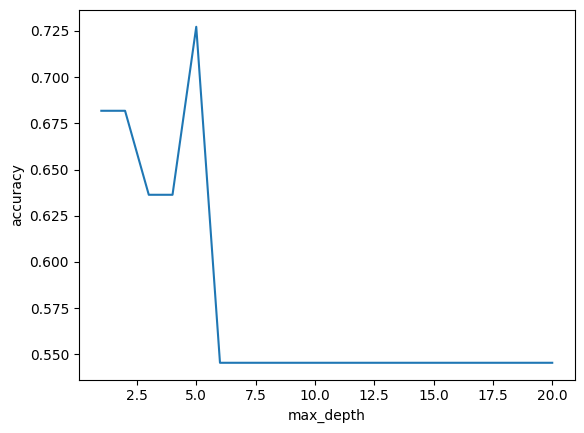

In [17]:
# Plotting accuracy vs depth
plt.plot(depths, acc_depth)
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.show()

Next, we want to see what the largest accuracy score within the classifier is, and at which depth this score occurs.

In [18]:
# Finding the largest accuracy score and its corresponding depth
max_acc = np.max(acc_depth)
best_depth = depths[np.argmax(acc_depth)]

# Displaying the results
print(f"Highest accuracy {round(max_acc,3)*100}% at depth {best_depth}")

Highest accuracy 72.7% at depth 5


Now that we have our depth with the highest accuracy, we must refit our decision tree model using this accuracy/depth pair.

In addition to this, we will be plotting the tree once refit.

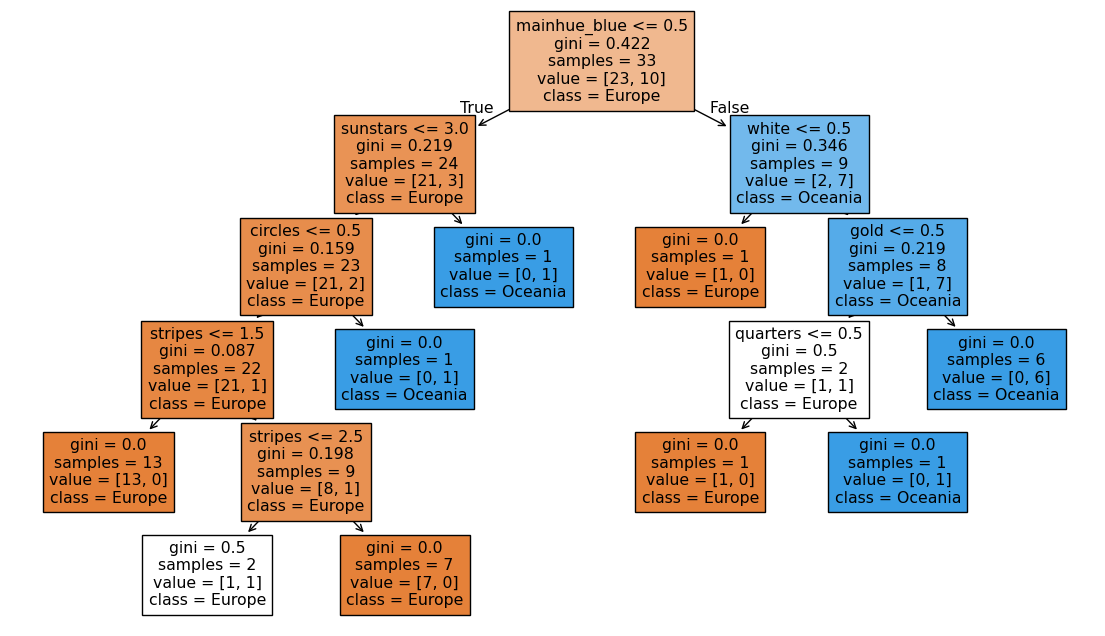

In [19]:
# Refitting and plotting tree
plt.figure(figsize=(14,8))
dt = DecisionTreeClassifier(random_state = 1, 
                            max_depth = best_depth)
dt.fit(train_data, train_labels)
tree.plot_tree(dt, feature_names = train_data.columns, 
               class_names = ['Europe', 'Oceania'], 
               filled=True)
plt.show()

## Tuning the Decision Tree Classifier by Pruning

Much like we did in the previous section using `max_depth`, we will now tune our decision tree by using the hyperparameter `ccp_alpha`, which is a pruning parameter.

To do this, we will fit a decision tree classifier for each value in `ccp`, and then will also append each of the accuracy scores corresponding to the `ccp` values in a list, `acc_pruned`.

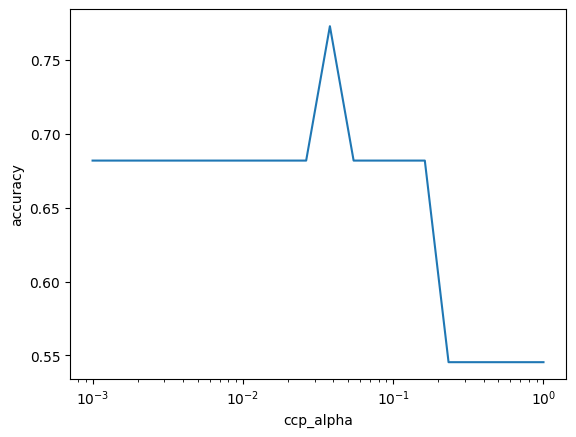

In [20]:
# Loop through values of ccp and append accuracy scores to acc_pruned
acc_pruned = []
ccp = np.logspace(-3, 0, num=20)
for i in ccp:
    dt_prune = DecisionTreeClassifier(random_state = 1, 
                                      max_depth = best_depth, 
                                      ccp_alpha=i)
    dt_prune.fit(train_data, train_labels)
    acc_pruned.append(dt_prune.score(test_data, test_labels))

# Plotting accuracy vs ccp_alpha
plt.plot(ccp, acc_pruned)
plt.xscale('log')
plt.xlabel('ccp_alpha')
plt.ylabel('accuracy')
plt.show()

Now again, much like we did in the previous section, we will need to establish the largest accuracy score and its corresponding ccp value.

In [22]:
# Finding the larges accuracy score and its corresponding ccp value
max_acc_pruned = np.max(acc_pruned)
best_ccp = ccp[np.argmax(acc_pruned)]

# Displaying the pair
print(f"Highest accuracy {round(max_acc_pruned,3)*100}% at ccp_alpha {round(best_ccp,4)}")

Highest accuracy 77.3% at ccp_alpha 0.0379


Now that we have the hioghest accuracy and its corresponding ccp value, we simply have to fit a new decision tree classifier with the values of `max_depth` and `ccp_alpha` found in the two sections above.

We will also plot the final decsion tree.

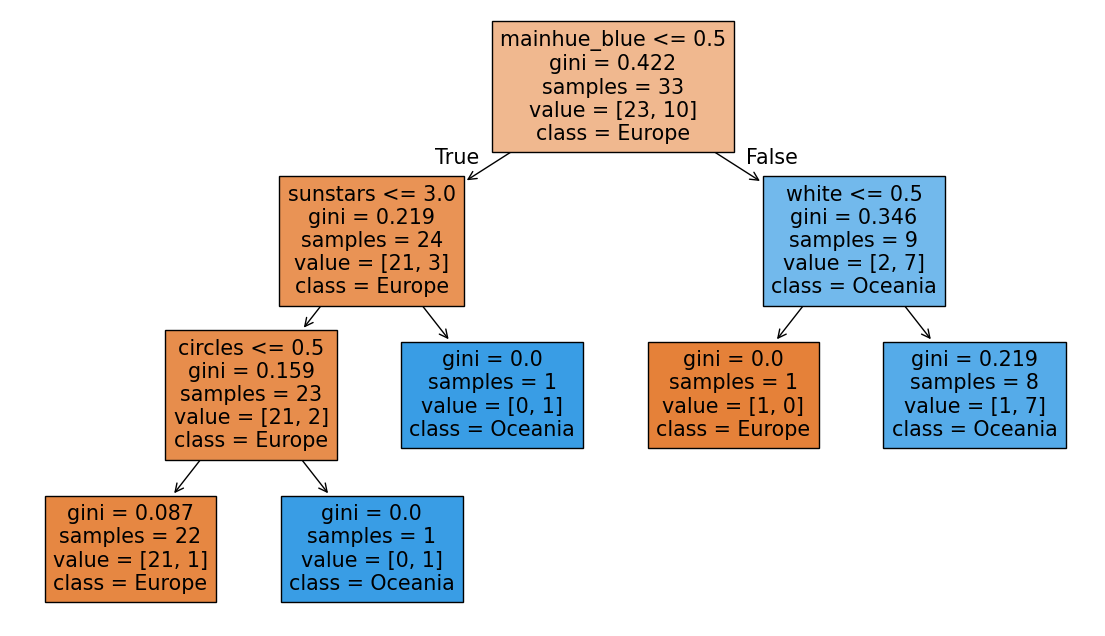

In [23]:
# Refitting and Plotting final decision tree
dt_final = DecisionTreeClassifier(random_state = 1, 
                                  max_depth = best_depth, 
                                  ccp_alpha = best_ccp)
dt_final.fit(train_data, train_labels)

# Plotting
plt.figure(figsize=(14,8))
tree.plot_tree(dt_final, feature_names = train_data.columns, 
               class_names = ['Europe', 'Oceania'], 
               filled=True)
plt.show()